## Correction note (metro/mall proximity)

An earlier version computed `metro_score` / `mall_score` as the **mean of label-encoded** `nearest_metro_en` / `nearest_mall_en` values — averaging arbitrary category IDs, which is meaningless. Those scores have been **replaced** by a distance proxy computed in the transactions step: the share of an area's records that have a known nearby metro / mall (range 0–1). The label/one-hot encoding cells that fed the old scores have been removed.


In [9]:
import pandas as pd
import numpy as np

## **STEP 1: IMPORTING THE DATASET**

Only importing relevent columns

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import pandas as pd
import zipfile

your_columns = [
    'contract_reg_type_id',
    'contract_reg_type_en',
    'contract_start_date',
    'contract_end_date',
    'contract_amount',
    'annual_amount',
    'no_of_prop',
    'line_number',
    'is_free_hold',
    'ejari_bus_property_type_id',
    'ejari_bus_property_type_en',
    'ejari_property_type_id',
    'ejari_property_type_en',
    'ejari_property_sub_type_id',
    'ejari_property_sub_type_en',
    'property_usage_en',
    'project_number',
    'master_project_en',
    'area_id',
    'area_name_en',
    'actual_area',
    'nearest_landmark_en',
    'nearest_metro_en',
    'nearest_mall_en',
    'tenant_type_id',
    'tenant_type_en'
]

zip_file_path = '/content/drive/MyDrive/dataset/rent_contracts_raw.csv.zip'
csv_file_in_zip = 'rent_contracts_2026-04-29_07-24-54_1.csv'

with zipfile.ZipFile(zip_file_path, 'r') as zf:
    with zf.open(csv_file_in_zip) as file_handle:
        df_large = pd.read_csv(
            file_handle,
            usecols=your_columns
        )

df_large = df_large[
    df_large['ejari_property_type_en'] == 'Office'
]

## **STEP2: DESCIBING OUR TABLE**

In [ ]:
df_large.info()

## **STEP3:DEALING WITH NULL EMPTY VALUES**

In [13]:
#check which all values are null
df_large.isnull().sum()

,0
contract_reg_type_id,0
contract_reg_type_en,0
contract_start_date,0
contract_end_date,0
contract_amount,0
annual_amount,0
no_of_prop,0
line_number,0
is_free_hold,0
ejari_bus_property_type_id,0


In [14]:
# for the missing values under actutal_are we take the median
df_large["actual_area"] = df_large["actual_area"].fillna(df_large['actual_area'].median())

In [15]:
#fill categorical text with "unknown"
text_cols = [
    'ejari_property_sub_type_en',
    'property_usage_en',
    'project_number',
    'master_project_en',
    'nearest_landmark_en',
    'nearest_metro_en',
    'nearest_mall_en',
    'tenant_type_en'
]

df_large[text_cols] = df_large[text_cols].fillna('Unknown')

HERE WE R BASICALLY CHECKY WHAT tenant_type_id MEANS AND HOW IT'S RELATED TO tenant_type_en
SO THAT WE CAN WORK ON THE NULL VALUES

In [16]:
df_large["tenant_type_en"].unique()

array(['Authority', 'Person', 'Unknown'], dtype=object)

In [17]:
df_large["tenant_type_id"].unique()

array([ 1.,  0., nan])

In [18]:
df_large['tenant_type_id'] = df_large['tenant_type_id'].fillna(-1)

In [19]:
df_large.groupby('tenant_type_en')['tenant_type_id'].unique()

,tenant_type_id
tenant_type_en,
Authority,[1.0]
Person,[0.0]
Unknown,[-1.0]


In [20]:
df_large.isnull().sum()

,0
contract_reg_type_id,0
contract_reg_type_en,0
contract_start_date,0
contract_end_date,0
contract_amount,0
annual_amount,0
no_of_prop,0
line_number,0
is_free_hold,0
ejari_bus_property_type_id,0


### Handling Nulls in `no_of_prop` and `is_free_hold`

Based on your input, we need to check and fill any missing values in `no_of_prop` and `is_free_hold`. For `no_of_prop`, we'll fill nulls with `1`, and for `is_free_hold`, we'll fill nulls with `0`.

In [21]:
# Check for nulls in these specific columns before filling
print("Nulls before filling 'no_of_prop' and 'is_free_hold':")
display(df_large[['no_of_prop', 'is_free_hold']].isnull().sum())

Nulls before filling 'no_of_prop' and 'is_free_hold':


,0
no_of_prop,0
is_free_hold,0


In [22]:
# Fill nulls in 'no_of_prop' with 1
df_large['no_of_prop'] = df_large['no_of_prop'].fillna(1)

# Fill nulls in 'is_free_hold' with 0
df_large['is_free_hold'] = df_large['is_free_hold'].fillna(0)

print("Nulls in 'no_of_prop' filled with 1, and 'is_free_hold' filled with 0.")

Nulls in 'no_of_prop' filled with 1, and 'is_free_hold' filled with 0.


In [23]:
# Verify null counts after filling
print("Nulls after filling 'no_of_prop' and 'is_free_hold':")
display(df_large[['no_of_prop', 'is_free_hold']].isnull().sum())

Nulls after filling 'no_of_prop' and 'is_free_hold':


,0
no_of_prop,0
is_free_hold,0


After these additions, the next step would be to re-run the entire preprocessing pipeline from the beginning to ensure these changes are applied before re-saving the final preprocessed CSV. I've placed these new cells right after the existing null-handling steps.

In [24]:
df_large.groupby(
    'ejari_property_sub_type_id'
)['ejari_property_sub_type_en'].unique()

,ejari_property_sub_type_en
ejari_property_sub_type_id,
-1.000000e+00,[Unknown]
0.000000e+00,[Unknown]
1.000000e+00,[1bed room+Hall]
2.000000e+00,[2 bed rooms+hall]
3.000000e+00,[3 bed rooms+hall]
4.000000e+00,[4 bed rooms+hall]
5.000000e+00,[5 bed rooms+hall]
1.100000e+01,[Studio]
1.900000e+01,[College]


In [25]:
df_large[['ejari_property_type_en',
          'ejari_property_sub_type_en']].drop_duplicates()

,ejari_property_type_en,ejari_property_sub_type_en
3,Office,Office
33,Office,1bed room+Hall
748,Office,2 bed rooms+hall
782,Office,Studio
4397,Office,College
5101,Office,Unknown
8293,Office,Clinic
8331,Office,4 bed rooms+hall
8992,Office,3 bed rooms+hall
11272,Office,Shop


### COMPUTING CONTRACT_DURATION

 convert the `contract_start_date` and `contract_end_date` columns to datetime objects, extract the year and month, and then calculate the `contract_duration_days`.

In [26]:
# Convert date columns to datetime objects
df_large['contract_start_date'] = pd.to_datetime(df_large['contract_start_date'])
df_large['contract_end_date'] = pd.to_datetime(df_large['contract_end_date'])

# Extract year and month
df_large['start_year'] = df_large['contract_start_date'].dt.year
df_large['start_month'] = df_large['contract_start_date'].dt.month
df_large['end_year'] = df_large['contract_end_date'].dt.year
df_large['end_month'] = df_large['contract_end_date'].dt.month

# Calculate contract duration in days
df_large['contract_duration_days'] = (df_large['contract_end_date'] - df_large['contract_start_date']).dt.days

print("Date engineering complete. New columns added:")
display(df_large[['contract_start_date', 'contract_end_date', 'start_year', 'start_month', 'end_year', 'end_month', 'contract_duration_days']].head())

Date engineering complete. New columns added:


,contract_start_date,contract_end_date,start_year,start_month,end_year,end_month,contract_duration_days
3,2024-01-15,2025-01-14,2024,1,2025,1,365
16,2020-10-01,2021-10-31,2020,10,2021,10,395
29,2015-06-01,2016-05-31,2015,6,2016,5,365
33,2022-05-05,2023-05-04,2022,5,2023,5,364
37,2023-12-10,2024-12-09,2023,12,2024,12,365


In [27]:
#check id contract_duration_days has any null values
df_large["contract_duration_days"].isnull().sum()

np.int64(0)

### Label Encoding for Categorical Columns
**LabelEncoder**:

This is from scikit-learn and is designed to transform categorical string labels into numerical labels.

**OrdinalEncoder** is designed to encode multiple columns simultaneously

### Confirming All String Values are Encoded

To verify that all relevant string (object) columns have been processed, we can check the data types of all columns in the `df_large` DataFrame. We expect to see very few 'object' type columns remaining, typically only those that were either part of the original data and not meant for encoding (like the original date columns before conversion) or columns that were deliberately kept.

In [28]:
print("Data types after all encoding steps:")
display(df_large.dtypes)

# Identify remaining 'object' type columns
object_cols_remaining = df_large.select_dtypes(include='object').columns.tolist()

# Filter out 'contract_start_date' and 'contract_end_date' if they are still objects (they should be datetime now)
# and 'ejari_property_type_en' which was constant and not encoded.

# Assuming contract_start_date and contract_end_date have been converted to datetime and are no longer 'object'
# The constant 'ejari_property_type_en' might still be an object if not dropped, but it's handled.

print(f"\nRemaining object columns (excluding those specifically handled or converted earlier): {object_cols_remaining}")

if not object_cols_remaining:
    print("No 'object' type columns remain in the DataFrame, indicating successful encoding or conversion of all relevant string fields.")
else:
    print("Please review the remaining object columns above. If any of these were intended for encoding, further processing might be needed.")

Data types after all encoding steps:


,0
contract_reg_type_id,int64
contract_reg_type_en,object
contract_start_date,datetime64[ns]
contract_end_date,datetime64[ns]
contract_amount,float64
annual_amount,float64
no_of_prop,int64
line_number,int64
is_free_hold,float64
ejari_bus_property_type_id,float64



Remaining object columns (excluding those specifically handled or converted earlier): ['contract_reg_type_en', 'ejari_bus_property_type_en', 'ejari_property_type_en', 'ejari_property_sub_type_en', 'property_usage_en', 'project_number', 'master_project_en', 'area_name_en', 'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en', 'tenant_type_en']
Please review the remaining object columns above. If any of these were intended for encoding, further processing might be needed.


### Saving the Preprocessed DataFrame

Now that all preprocessing steps (missing value handling, feature engineering, and encoding) are complete, we can save the final `df_large` DataFrame to a new CSV file. This allows you to easily load this processed data for subsequent modeling tasks without re-running the entire preprocessing pipeline.

### Dropping Original Categorical Columns

Now that we have created numerical representations for our categorical features through Label Encoding and One-Hot Encoding, we can drop the original string-based columns to avoid redundancy and potential issues in machine learning models.

In [29]:
# List of original categorical columns that have been encoded or are no longer needed
# This list comes from the 'object_cols_remaining' identified in the previous step.
drop_cols = [
    'contract_reg_type_en',
    'ejari_bus_property_type_en',
    'ejari_property_type_en', # Was constant 'Office', so can be dropped if not needed
    'ejari_property_sub_type_en',
    'property_usage_en',
    'project_number',
    'master_project_en',
    'area_name_en',
    'nearest_landmark_en',
    'nearest_metro_en',
    'nearest_mall_en',
    'tenant_type_en'
]

# Drop these columns from the DataFrame
df_large = df_large.drop(columns=drop_cols)

print(f"Dropped the following original categorical columns: {drop_cols}")

print("\nData types after dropping original categorical columns:")
display(df_large.dtypes)

object_cols_after_drop = df_large.select_dtypes(include='object').columns.tolist()
if not object_cols_after_drop:
    print("\nAll original categorical 'object' columns have been successfully dropped.")
else:
    print(f"\nRemaining 'object' columns: {object_cols_after_drop}. Please review if these were intended to be kept.")

Dropped the following original categorical columns: ['contract_reg_type_en', 'ejari_bus_property_type_en', 'ejari_property_type_en', 'ejari_property_sub_type_en', 'property_usage_en', 'project_number', 'master_project_en', 'area_name_en', 'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en', 'tenant_type_en']

Data types after dropping original categorical columns:


,0
contract_reg_type_id,int64
contract_start_date,datetime64[ns]
contract_end_date,datetime64[ns]
contract_amount,float64
annual_amount,float64
no_of_prop,int64
line_number,int64
is_free_hold,float64
ejari_bus_property_type_id,float64
ejari_property_type_id,float64



All original categorical 'object' columns have been successfully dropped.


### Removing Original Date Columns

Since we have already extracted useful numerical features such as `start_year`, `start_month`, `end_year`, `end_month`, and `contract_duration_days` from the `contract_start_date` and `contract_end_date` columns, the original datetime columns are no longer needed for modeling and can be removed to reduce redundancy.

### Final Save of the Preprocessed DataFrame

After dropping the original categorical columns, we should save the updated DataFrame to reflect these final changes, making it ready for direct use in modeling.

In [30]:
# Drop the original datetime columns as their information has been extracted into numerical features
drop_date_cols = ['contract_start_date', 'contract_end_date']
df_large = df_large.drop(columns=drop_date_cols)

print(f"Dropped the following original datetime columns: {drop_date_cols}")

print("\nRemaining columns and their types:")
display(df_large.dtypes)

Dropped the following original datetime columns: ['contract_start_date', 'contract_end_date']

Remaining columns and their types:


,0
contract_reg_type_id,int64
contract_amount,float64
annual_amount,float64
no_of_prop,int64
line_number,int64
is_free_hold,float64
ejari_bus_property_type_id,float64
ejari_property_type_id,float64
ejari_property_sub_type_id,float64
area_id,float64


In [32]:
print(df_large.columns.tolist())

['contract_reg_type_id', 'contract_amount', 'annual_amount', 'no_of_prop', 'line_number', 'is_free_hold', 'ejari_bus_property_type_id', 'ejari_property_type_id', 'ejari_property_sub_type_id', 'area_id', 'actual_area', 'tenant_type_id', 'start_year', 'start_month', 'end_year', 'end_month', 'contract_duration_days']


### Checking for Outliers in `df_area_table`

Outliers can be present in numerical columns and might indicate data entry errors, rare events, or genuinely extreme values. We'll examine `avg_rent`, `contract_count`, `metro_score`, and `mall_score` for outliers using visualizations (box plots) and the Interquartile Range (IQR) method.

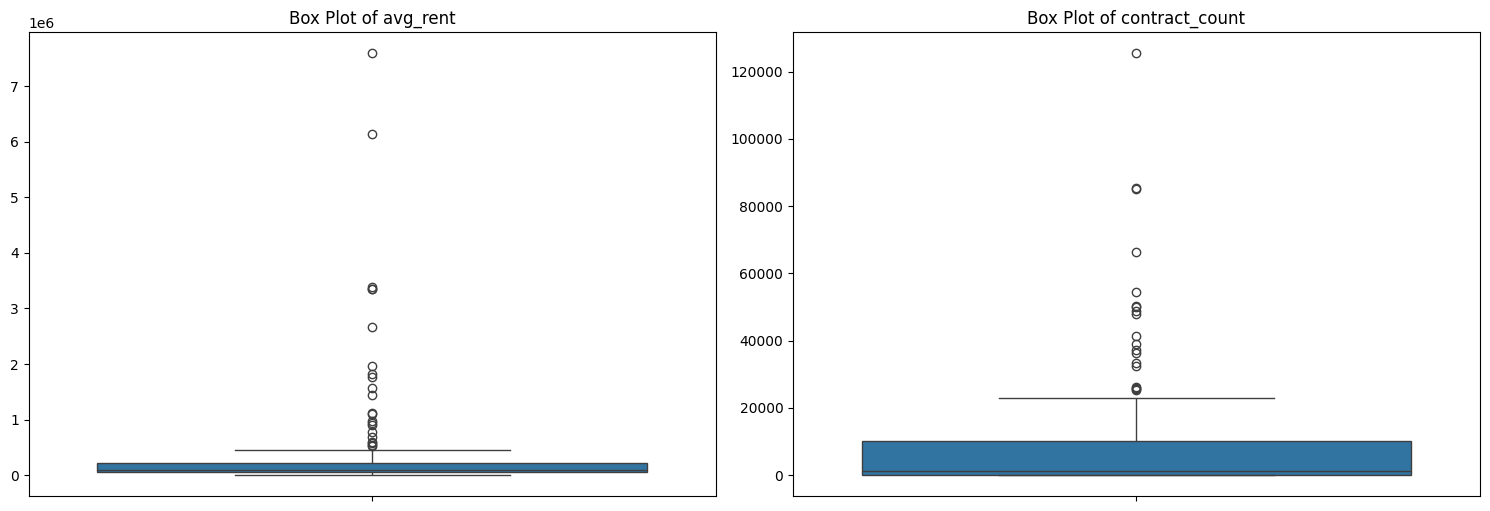

In [35]:
# Aggregate office rent contracts to district level.
# NOTE: metro_score / mall_score are NOT computed here. The earlier approach
# (mean of LABEL-ENCODED station/mall names) was invalid, so proximity is
# instead derived in the transactions step as the share of records with a
# known nearby metro/mall (see ../data/area_proximity_recompute.csv).
import pandas as pd
df_area_table = df_large.groupby('area_id').agg(
    avg_rent=('annual_amount', 'mean'),
    contract_count=('contract_reg_type_id', 'count')
).reset_index()
# df_area_table.head() # This line is removed as it's not needed for the plotting

import matplotlib.pyplot as plt
import seaborn as sns

# Columns to check for outliers
outlier_cols = ['avg_rent', 'contract_count']

plt.figure(figsize=(15, 10))
for i, col in enumerate(outlier_cols):
    plt.subplot(2, 2, i + 1)  # Create a 2x2 grid of plots
    sns.boxplot(y=df_area_table[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('') # Remove y-label to avoid clutter
plt.tight_layout()
plt.show()

From the box plots, we can visually identify potential outliers. Now, let's use the Interquartile Range (IQR) method to programmatically find outliers. The IQR method defines outliers as any values that fall below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR.

In [36]:
# Function to detect outliers using IQR method
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("\n--- Outlier Detection using IQR Method ---")
for col in outlier_cols:
    outliers, lower_bound, upper_bound = find_outliers_iqr(df_area_table, col)
    if not outliers.empty:
        print(f"\nColumn: {col}")
        print(f"  Number of outliers: {len(outliers)}")
        print(f"  Lower Bound: {lower_bound:.2f}")
        print(f"  Upper Bound: {upper_bound:.2f}")
        # Optionally display the outliers themselves
        # print("  Outlier values:")
        # display(outliers[[col]])
    else:
        print(f"\nColumn: {col}: No significant outliers detected by IQR method.")


--- Outlier Detection using IQR Method ---

Column: avg_rent
  Number of outliers: 22
  Lower Bound: -199301.44
  Upper Bound: 473908.24

Column: contract_count
  Number of outliers: 19
  Lower Bound: -14821.25
  Upper Bound: 24884.75


The output above shows how many outliers were detected for each column based on the IQR method. Now, we need to decide how to handle these:

1.  **Remove them**: This is suitable if outliers are due to data errors and represent a small fraction of your data.
2.  **Cap them (Winsorization)**: Replace outlier values with the nearest non-outlier value (e.g., replace values above the upper bound with the upper bound itself). This retains more data than removal.
3.  **Transform them**: Apply a mathematical transformation (like log or square root) to reduce the impact of extreme values.

Which approach would you prefer for these identified outliers?

### Outlier Handling: Capping (Winsorization)

Based on your decision, we will cap the outliers in `avg_rent` and `contract_count`. This means that any value below the calculated lower bound will be set to the lower bound, and any value above the upper bound will be set to the upper bound. This approach helps to reduce the impact of extreme values without removing them entirely from the dataset.

In [37]:
# Function to cap outliers using IQR bounds
def cap_outliers_iqr(df, column, lower_bound, upper_bound):
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df

print("--- Capping Outliers using IQR Method ---")

# Apply capping to 'avg_rent'
outliers_avg_rent, lower_bound_rent, upper_bound_rent = find_outliers_iqr(df_area_table, 'avg_rent')
df_area_table = cap_outliers_iqr(df_area_table, 'avg_rent', lower_bound_rent, upper_bound_rent)
print(f"Capped outliers for 'avg_rent'. Values below {lower_bound_rent:.2f} and above {upper_bound_rent:.2f} have been adjusted.")

# Apply capping to 'contract_count'
outliers_contract_count, lower_bound_count, upper_bound_count = find_outliers_iqr(df_area_table, 'contract_count')
df_area_table = cap_outliers_iqr(df_area_table, 'contract_count', lower_bound_count, upper_bound_count)
print(f"Capped outliers for 'contract_count'. Values below {lower_bound_count:.2f} and above {upper_bound_count:.2f} have been adjusted.")

print("\nDescriptive statistics after capping:")
display(df_area_table[['avg_rent', 'contract_count']].describe())

--- Capping Outliers using IQR Method ---
Capped outliers for 'avg_rent'. Values below -199301.44 and above 473908.24 have been adjusted.
Capped outliers for 'contract_count'. Values below -14821.25 and above 24884.75 have been adjusted.

Descriptive statistics after capping:


,avg_rent,contract_count
count,168.000000,168.000000
mean,167256.367240,5994.590774
std,152205.094340,8554.404875
min,1000.000000,1.000000
25%,53152.191475,68.500000
50%,98415.770581,1219.500000
75%,221454.612563,9995.000000
max,473908.244195,24884.750000


#SAVING OUR PRE-PROCESSED FILE (WITHOUT AGGREGATION)

In [38]:
output_file_path_final = '/content/drive/MyDrive/dataset/rents_preprocessed_final1.0.csv'
df_large.to_csv(output_file_path_final, index=False)
print(f"Final preprocessed DataFrame saved to: {output_file_path_final}")

Final preprocessed DataFrame saved to: /content/drive/MyDrive/dataset/rents_preprocessed_final1.0.csv


In [41]:
# Aggregate office rent contracts to district level.
# NOTE: metro_score / mall_score are NOT computed here. The earlier approach
# (mean of LABEL-ENCODED station/mall names) was invalid, so proximity is
# instead derived in the transactions step as the share of records with a
# known nearby metro/mall (see ../data/area_proximity_recompute.csv).
df_area_table = df_large.groupby('area_id').agg(
    avg_rent=('annual_amount', 'mean'),
    contract_count=('contract_reg_type_id', 'count'),
).reset_index()
df_area_table.head()


,area_id,avg_rent,contract_count
0,230.0,25100.185100,11297
1,231.0,75793.572191,5938
2,232.0,199651.961889,397
3,233.0,22897.687917,48705
4,234.0,71716.020395,19891


In [40]:
# Define the output path for the new CSV file
output_file_path_area_table = '/content/drive/MyDrive/dataset/area_table_1.csv'

# Save the new DataFrame to a CSV file
df_area_table.to_csv(output_file_path_area_table, index=False)

print(f"Area table saved to: {output_file_path_area_table}")

Area table saved to: /content/drive/MyDrive/dataset/area_table_1.csv
